
# Custom Dataset

In [110]:
# 0. Setting up device agnostic code
import torch
from torch import nn # Neural Networks

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [111]:
# Check torch version
torch.__version__

'2.8.0+cu126'

#### Get the data
* Create custom dataset from food101 library


In [112]:
import torchvision # for image classification

torch.__version__, torchvision.__version__

('2.8.0+cu126', '0.23.0+cu126')

In [113]:
import torchvision.datasets as datasets
import pathlib
data_dir = pathlib.Path("/content/drive/MyDrive/Custom_Dataset/sample_data")

In [114]:
# Getting the train and testset
# downloading the data

# train data
trainset = datasets.Food101(root=data_dir,split="train",download=True)
# test data
testset = datasets.Food101(root=data_dir,split="test",download=True)


In [115]:
len(trainset), len(testset)

(75750, 25250)

In [116]:
classes = trainset.classes
classes[:200]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

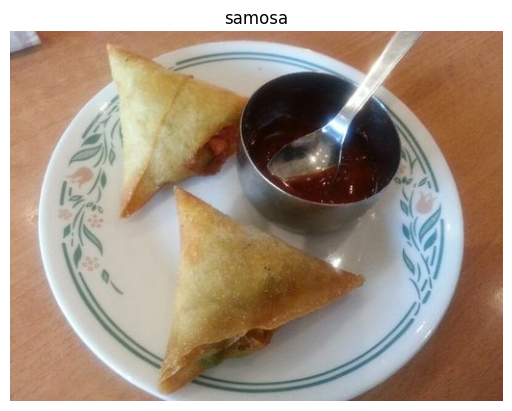

In [117]:
import matplotlib.pyplot as plt

img = trainset[2010][0]
plt.imshow(img)
plt.axis('off')
plt.title(classes[trainset[2010][1]])
plt.show()

In [213]:
# Find subset for appropriate class samosa, cheesecake, lasagana
import random

# Set up data paths
data_path = data_dir / "food-101" / "images"
target_classes = ["hamburger","sushi","spaghetti_bolognese"]
# change amount of radom data to get
amount = 0.2
# Create function to seperate a random amount of data
def get_subset(image_path=data_path,
               data_splits=["train", "test"],
               target_classes = target_classes,
               amount=amount,
               seed=42):
  # Get Labels
  random.seed(42)
  label_splits = {}

  for data_split in data_splits:
    print(f"[INFO] Creating image splits for: {data_split}...")
    label_path = data_dir/"food-101"/"meta"/f"{data_split}.txt"
    with open(label_path, "r") as f:
      labels = [line.strip("\n") for line in f.readlines() if line.split("/")[0] in target_classes] # so zero defines the part before / in list [something1/somtheing2]
    # Get random subset of target classes image ID's
    number_to_sample = round(len(labels) * amount)
    print(f"[INFO] Getting random subsets of {number_to_sample} images for {data_split} data.....")
    sampled_images = random.sample(labels, k=number_to_sample)
    # Apply full paths
    image_paths = [pathlib.Path(str(image_path/sample_image) +".jpg") for sample_image in sampled_images]
    label_splits[data_split] = image_paths
  return label_splits

label_splits = get_subset(amount=amount)
label_splits["train"[:10]]




[INFO] Creating image splits for: train...
[INFO] Getting random subsets of 450 images for train data.....
[INFO] Creating image splits for: test...
[INFO] Getting random subsets of 150 images for test data.....


[PosixPath('/content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/hamburger/3289634.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/hamburger/1492254.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/spaghetti_bolognese/2755183.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/spaghetti_bolognese/2292118.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/spaghetti_bolognese/1792464.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/hamburger/3878886.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/hamburger/3101158.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/sushi/93139.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/hamburger/2726558.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset

In [214]:
# Moving training and testing data to dedicated folders

# Target directory path

target_dir_name = f"/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese{str(int(amount*100))}_percent"
print(f"Creting directory : {target_dir_name}")
# setup the directory
target_dir = pathlib.Path(target_dir_name)

# make the dir
target_dir.mkdir(parents=True, exist_ok=True)

Creting directory : /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent


In [120]:
!pip install google

In [215]:
# connect to drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [216]:
label_splits.keys()

dict_keys(['train', 'test'])

In [217]:
import shutil # copy, delete, move and manage files & directors

for image_split in label_splits.keys():
    for image_path in label_splits[str(image_split)]:
      dest_dir = target_dir /image_split/image_path.parent.stem/image_path.name
      if not dest_dir.parent.is_dir():
        dest_dir.parent.mkdir(parents=True, exist_ok=True)
      print(f"[INFO] Copying {image_path} to {dest_dir}...")
      shutil.copy2(image_path, dest_dir)



[INFO] Copying /content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/hamburger/3289634.jpg to /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent/train/hamburger/3289634.jpg...
[INFO] Copying /content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/hamburger/1492254.jpg to /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent/train/hamburger/1492254.jpg...
[INFO] Copying /content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/spaghetti_bolognese/2755183.jpg to /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent/train/spaghetti_bolognese/2755183.jpg...
[INFO] Copying /content/drive/MyDrive/Custom_Dataset/sample_data/food-101/images/spaghetti_bolognese/2292118.jpg to /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent/train/spaghetti_bolognese/2292118.jpg...
[INFO] Copying /content/drive/MyDrive/Custom_Dataset/sample_data/food-101/im

In [218]:
# Check lengths of directories
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str): target directories

  Returns:
    A print out of:
      number of subdirectories in dir_path
      number of images (files) in each subdirectories
      name of each subdirectory
  """
  import os
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(target_dir)


There are 2 directories and 0 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent'.
There are 3 directories and 0 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent/train'.
There are 0 directories and 154 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent/train/hamburger'.
There are 0 directories and 146 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent/train/spaghetti_bolognese'.
There are 0 directories and 150 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent/train/sushi'.
There are 3 directories and 0 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent/test'.
There are 0 directories and 58 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese20_percent/test/spaghetti_bolognese'.
There are 0 di

In [219]:
## Zip up images folderr to be more easily transported


zip_file_name = data_dir / f"hamburger_sushi_spaghetti_bolognese_{str(int(amount*100))}_percent"
shutil.make_archive( zip_file_name, "zip", root_dir=target_dir)


'/content/drive/MyDrive/Custom_Dataset/sample_data/hamburger_sushi_spaghetti_bolognese_20_percent.zip'

In [220]:
import os

os.listdir(data_dir)

['food-101.tar.gz',
 'food-101',
 'hamburger_sushi_spaghetti_bolognese_20_percent.zip']

In [221]:
!ls -la ../content/

total 20
drwxr-xr-x 1 root root 4096 Nov  2 18:05 .
drwxr-xr-x 1 root root 4096 Nov  2 18:03 ..
drwxr-xr-x 4 root root 4096 Oct 30 13:36 .config
drwx------ 5 root root 4096 Nov  2 18:05 drive
drwxr-xr-x 1 root root 4096 Oct 30 13:36 sample_data


In [223]:
!mkdir -p /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese


In [226]:
!unzip  /content/drive/MyDrive/Custom_Dataset/sample_data/hamburger_sushi_spaghetti_bolognese_20_percent.zip -d /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese

Archive:  /content/drive/MyDrive/Custom_Dataset/sample_data/hamburger_sushi_spaghetti_bolognese_20_percent.zip
   creating: /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/test/
   creating: /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/train/
   creating: /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/train/hamburger/
   creating: /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/train/spaghetti_bolognese/
   creating: /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/train/sushi/
  inflating: /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/train/hamburger/3289634.jpg  
  inflating: /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/train/hamburger/1492254.jpg  
  inflating: /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/train/hamburger/3878886.jpg  
  inflating: /content/drive/MyDri

In [227]:
walk_through_dir("/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese")

There are 2 directories and 0 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese'.
There are 3 directories and 0 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/test'.
There are 0 directories and 46 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/test/hamburger'.
There are 0 directories and 58 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/test/spaghetti_bolognese'.
There are 0 directories and 46 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/test/sushi'.
There are 3 directories and 0 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/train'.
There are 0 directories and 154 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese/train/hamburger'.
There are 0 directories and 146 images in '/content/drive/MyDrive/Custom_Dataset/hamburger_sushi_s

In [228]:
!ls

drive  sample_data


In [229]:
# Setup train and testing paths
from pathlib import Path


image_path = "/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese"
train_dir = Path(image_path) / "train"
test_dir = Path(image_path) / "test"

train_dir, test_dir


(PosixPath('/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/train'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test'))

In [230]:
import shutil
import os

# Remove .ipynb_checkpoints directory if it exists in train_dir and test_dir
if os.path.exists(os.path.join(train_dir, ".ipynb_checkpoints")):
    shutil.rmtree(os.path.join(train_dir, ".ipynb_checkpoints"))
    print(f"Removed: {os.path.join(train_dir, '.ipynb_checkpoints')}")
if os.path.exists(os.path.join(test_dir, ".ipynb_checkpoints")):
    shutil.rmtree(os.path.join(test_dir, ".ipynb_checkpoints"))
    print(f"Removed: {os.path.join(test_dir, '.ipynb_checkpoints')}")

## Domain Libraries:

Depending on what you're working on, vision, text, audio recommendation, you'll want to look into each of the PyTorch domain libraries for exisiting data loading functions and customizable data loading function

In [234]:
walk_through_dir("/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese")

In [232]:
!mkdir /content/drive/MyDrive/Custom_Dataset/data


mkdir: cannot create directory ‘/content/drive/MyDrive/Custom_Dataset/data’: File exists


In [237]:
!mv /content/drive/MyDrive/Custom_Dataset/hamburger_sushi_spaghetti_bolognese /content/drive/MyDrive/Custom_Dataset/data

# Visualization



Image path : /content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/sushi/2743100.jpg
Image class name: sushi
Image height: 512
Image with: 512


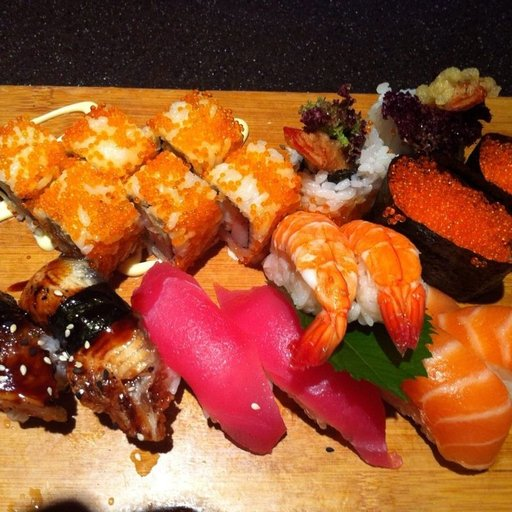

In [238]:
#imports
from PIL import Image
import glob
import random
import pathlib # Import pathlib

# Set Seed
random.seed(42)
# Convert image_path to a Path object
image_path = pathlib.Path(image_path) # Convert to Path object
# Get all images
image_path_list = list(image_path.glob("*/*/*.jpg"))
# Get random image path
random_image_path = random.choice(image_path_list)
# Get the class of the image
image_class = random_image_path.parent.stem # Corrected typo
# Open image
img = Image.open(random_image_path)
# print
print(f"Image path : {random_image_path}")
print(f"Image class name: {image_class}")
print(f"Image height: {img.height}")
print(f"Image with: {img.width}")
img

# Image Transformation
* So next we need to load the data into Pytorch
* For the same we need to, Transform the data into the numerical representation of the images
* Transform them into `torch.utils.data.Datasets` and DataLoader for Pytorch
### 0. Libraries

* `torchvision` base domain libraries for computer vision
* `torchvision.datasets` - get datasets and data loadding functions for computer vision
* `trochvision.models` - get pretrained computer vision models that you can leverage
* `torch.transforms` - functions for manipulatinng your vison data(images) to be suitable for use with an ML model
* `torch.utils.data.Dataset` - Base dataset class for Pytorch
* `torch.uttils.data.DataLoader` - Creates a Python iterable over a dataset

In [239]:
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torchvision.__version__

'0.23.0+cu126'

### So now w need to transform the image from a PIL image to a tensor representation FOR he same we will be using:
* `torchvision.transforms` for image transformation library
* `transforms.Resize()` - to reduce image size
* `transforms.RandomHorizontalFlip` - for data augumentaiton  (data augumentaion is used to artificially vary the datset for creating diversity, by various methods like scalling, fliping, rotation, color adjustment etc, To prevent `Overfitting` And `Enhanced Genralization`)

* `tranforms.ToTensor()`- For finally transforming it into a torch readable format

* `transforms.Compose` - To bind ths together into a function



In [240]:
data_transform = transforms.Compose([
    # Resizing the image
    transforms.Resize(size=(64,64)),
    # data sugumentation
    transforms.RandomHorizontalFlip(p=0.5), # probability of flip is 50%
    # Converting it to a tensor
    transforms.ToTensor() # this also converts the image size form between 0 to 255 to 0.0 to 0.1 (like a sigmoid)
])

In [241]:
import matplotlib.pyplot as plt
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_path = random.sample(image_paths, k=n)
    for image_path in random_image_path:
      with Image.open(image_path) as f:
        fig, ax = plt.subplots(1,2)

        ax[0].imshow(f)
        ax[0].set_title(f"Original \n Size: {f.size}")
        ax[0].axis("off")

        # Transform image
        transformed_img  = transform(f).permute(1,2,0)
        ax[1].imshow(transformed_img)
        ax[1].set_title(f"Transformed \n size: {transformed_img.shape}")
        ax[1].axis("off")

        fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


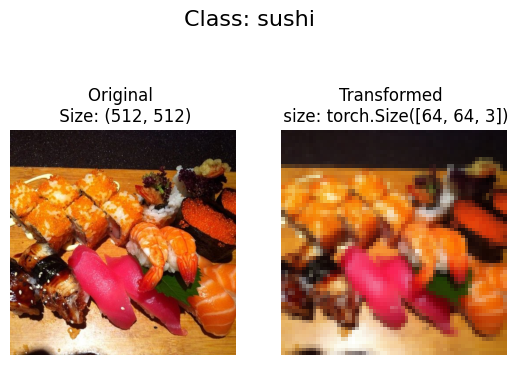

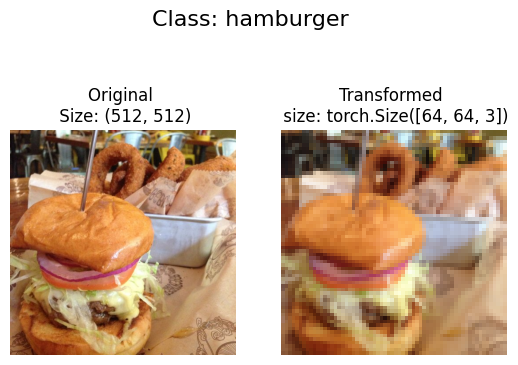

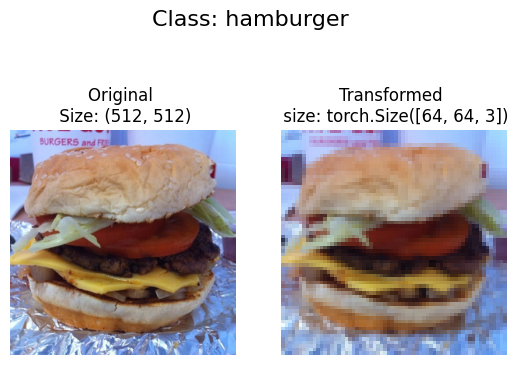

In [242]:
plot_transformed_images(image_path_list, data_transform, n=3)

#### So What we learned frm this is:
* First get the data store it to certain directory
* Then Transform it using the
* `torchvison.transforms`
`Resize(to the cnn format 64,64) -> perform data augumentation -> Conver the data to the tensor for pytorch operations`

# Turn image data into Dataset compatible to running with Pytorch
* We can use `torchvision.datasets.ImageFolder`. So, we can pass it the file path of a target image directory as well as a series of transforms we'd like to perform on our images


In [243]:
from torchvision import datasets
import shutil
import os

# Remove .ipynb_checkpoints directory if it exists in train_dir and test_dir
if os.path.exists(os.path.join(train_dir, ".ipynb_checkpoints")):
    shutil.rmtree(os.path.join(train_dir, ".ipynb_checkpoints"))
    print(f"Removed: {os.path.join(train_dir, '.ipynb_checkpoints')}")
if os.path.exists(os.path.join(test_dir, ".ipynb_checkpoints")):
    shutil.rmtree(os.path.join(test_dir, ".ipynb_checkpoints"))
    print(f"Removed: {os.path.join(test_dir, '.ipynb_checkpoints')}")


train_data = datasets.ImageFolder(root=train_dir,
                                transform=data_transform, # performs transform on the data (images)
                                target_transform=None, # performs transforms on label if needed
                                )
test_data = datasets.ImageFolder(root=test_dir,
                               transform=data_transform,
                                )
print(f"Train data \n : {train_data} \n , Test data \n : {test_data}")

Train data 
 : Dataset ImageFolder
    Number of datapoints: 450
    Root location: /content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           ) 
 , Test data 
 : Dataset ImageFolder
    Number of datapoints: 150
    Root location: /content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [244]:
class_names = train_data.classes
class_names

['hamburger', 'spaghetti_bolognese', 'sushi']

###### can also get the class name as a dictionary using `class_to_idx`

In [245]:
class_dict = train_data.class_to_idx
class_dict

{'hamburger': 0, 'spaghetti_bolognese': 1, 'sushi': 2}

In [246]:
len(train_data), len(test_data)

(450, 150)

In [252]:
img, label = train_data[1][0], train_data[1][1]
print(f"image tensor: {img} \n image data type: {img.dtype} \n image shape : {img.shape}")
print(f"Label : {label} \n Label datatype : {type(label)}")

image tensor: tensor([[[0.4275, 0.4431, 0.4706,  ..., 0.2118, 0.2078, 0.2039],
         [0.4549, 0.5059, 0.5059,  ..., 0.2078, 0.2078, 0.2039],
         [0.5412, 0.5373, 0.4902,  ..., 0.2157, 0.2235, 0.2196],
         ...,
         [0.4039, 0.3961, 0.4078,  ..., 0.0039, 0.0039, 0.0039],
         [0.4000, 0.4000, 0.4000,  ..., 0.0039, 0.0039, 0.0039],
         [0.3843, 0.3804, 0.3725,  ..., 0.0039, 0.0039, 0.0039]],

        [[0.4863, 0.5020, 0.5294,  ..., 0.2784, 0.2706, 0.2706],
         [0.5137, 0.5647, 0.5647,  ..., 0.2784, 0.2706, 0.2706],
         [0.6157, 0.6000, 0.5451,  ..., 0.2745, 0.2706, 0.2745],
         ...,
         [0.3843, 0.3843, 0.3804,  ..., 0.0039, 0.0039, 0.0039],
         [0.3804, 0.3843, 0.3843,  ..., 0.0039, 0.0039, 0.0039],
         [0.3725, 0.3725, 0.3686,  ..., 0.0039, 0.0039, 0.0039]],

        [[0.5059, 0.5216, 0.5490,  ..., 0.3569, 0.3490, 0.3373],
         [0.5255, 0.5725, 0.5765,  ..., 0.3529, 0.3451, 0.3451],
         [0.6431, 0.6196, 0.5647,  ..., 0.34

Text(0.5, 1.0, 'hamburger')

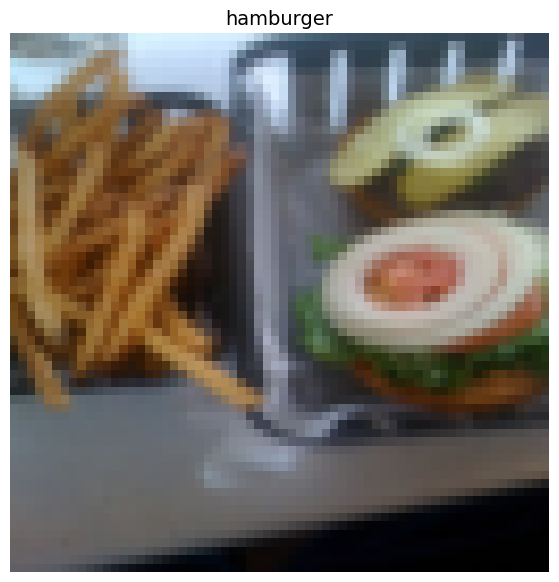

In [253]:
img_permuted = img.permute(1,2,0)

plt.figure(figsize=(10,7))
plt.imshow(img_permuted)
plt.axis("off")
plt.title(class_names[label], fontsize=14)

# Turn loaded images into Dataloader
* `DataLoader` is a utility designed to efficiently manage and load data for model training or inference.
* Turning our `Dataset's` into `DataLoader's` makes them iterable
* Use `torch.utils.data.Dataloader`
* We will use the `batch_size=1` and `num_workers=2` -> defines how many subprocesses will be created to load your data.(how much power pytorch wil consume of cpu to laod the data, usually num of cpu in your system to get the same use `os.cpu_count()`). This ensures the `DataLoader` uses as many cores as possible to load the data

In [254]:
import os
os.cpu_count()

2

In [255]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1,
                              num_workers=2,
                              shuffle=True
)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=2,
                             shuffle=True)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7db4d00feab0>,
 <torch.utils.data.dataloader.DataLoader at 0x7db4d0327650>)

In [256]:
img, label = next(iter(test_dataloader))

print(f"Image Shape: {img.shape}")
print(f"Label Shape: {label.shape}")

Image Shape: torch.Size([1, 3, 64, 64])
Label Shape: torch.Size([1])



We could now use these `DataLoader`'s with a training and testing loop to train a model.

### Option 2: Loading Image data with Custom dataset


In [257]:
# Import Libraries
import os # For handling driectories
import pathlib # For dealing with filepaths
import torch

from PIL import Image
from torch.utils.data import Dataset # To subclas and create our own custom datset
from torchvision import transforms# To transform data to Tensors
from typing import Tuple, Dict, List

train_data.classes, test_data.classes

(['hamburger', 'spaghetti_bolognese', 'sushi'],
 ['hamburger', 'spaghetti_bolognese', 'sushi'])

In [258]:
# Creating a helper function for getting the class names

target_dir = train_dir
print(target_dir)

class_names_found = sorted([entry.name for entry in (os.scandir(image_path/"train"))])
print(f"Class names: {class_names_found}")

/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/train
Class names: ['hamburger', 'spaghetti_bolognese', 'sushi']


In [259]:
# lets turn this into directory
# Make function to find the casses in the target directory

def find_classes(directory : str) -> Tuple[List[str] , Dict[str, int]]:
  """
  Finds the class folder names in a target directory.

    Assumes target directory is in standard image classification format.

    Args:
        directory (str): target directory to load classnames from.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))

    Example:
        find_classes("food_images/train")
        >>> (["class_1", "class_2"], {"class_1": 0, ...})
  """
  # Scan the directory for the classes
  try:
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
  except FileNotFoundError:
    print(f"{directory}  does not exists")
  if not classes:
    print(f"No class found in {directory}")
  # create a dictonary
  class_to_idx = {cls_name : i for i , cls_name in enumerate(classes)}
  return classes, class_to_idx


In [260]:
find_classes(train_dir)

(['hamburger', 'spaghetti_bolognese', 'sushi'],
 {'hamburger': 0, 'spaghetti_bolognese': 1, 'sushi': 2})

#### Create a custom `Dataset` to replicate the ImageFolder


1.   Subclass `torchutils.data.Dataset`
2.   Init our subclass with a target directory (the directory we'd like to get data from) as well as a transform if we'd like to transform our data.
3.   Create Serceral attributes:
  * paths - paths of all our images
  * transform - the transform we'd like to use
  * classes - a list of the target classes
  * class_to_idx - a dict of the target classes mapped to integer labels
4.   Create a function to `load_images()` , this funtion will open an image
5.   Overwrite the `__len()__` method to return the length of our dataset
6.   Overwrite the `__getitem()__` method to return a given sample when passed a index


In [261]:
from torch.utils.data import Dataset
from PIL import Image

# 1. subclass
class CustomImageFolder(Dataset):
  # 2. subclass torchutils.data.Dataset
  def __init__(self, target_dir: str, transform=None) -> None:
    # 3. Create class attributes:
    # Get all of the image paths
    self.path = list(pathlib.Path(target_dir).glob("*/*.jpg"))
    # Setup transform
    self.transform = transform
    # setup list of target classes
    self.classes, self.class_to_idx = find_classes(target_dir)
  # 4 write a funtion to load_images():
  def load_image(self, index: int) -> Image.Image:
    'Opens an image via a path and returns it'
    image_path = self.path[index]
    return Image.open(image_path)
  # 5. create a function to overwrite the dunder len method:
  def __len__(self) -> int: # -> this is used to determine what the output datatype must be
    return len(self.path)
  # 6. OVerwrite the __getitem__
  def __getitem__(self, index : int) -> Tuple[torch.Tensor, int]: # same thing what we get when we index on our training data
    "Returns one random sample of the data, data and label (X,y)"
    img = self.load_image(index)
    class_name = self.path[index].parent.name # demands path in format : data_folder/class_name/image.jpg
    class_idx = self.class_to_idx[class_name]

    # Transfom if neccessary
    if self.transform:
      return self.transform(img) , class_idx # retrun data, label (X, y)
    else:
      return img, class_idx

In [262]:
# create transforms to prepare images

train_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
                                       ])
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])


In [263]:
train_data_custom = CustomImageFolder(train_dir, train_transforms)
test_data_custom = CustomImageFolder(test_dir, test_transforms)

test_data_custom, test_data_custom

(<__main__.CustomImageFolder at 0x7db4d02a2f60>,
 <__main__.CustomImageFolder at 0x7db4d02a2f60>)

In [264]:
len(train_data_custom), len(test_data_custom)

(450, 150)

In [265]:
train_data_custom.classes

['hamburger', 'spaghetti_bolognese', 'sushi']

In [266]:
train_data_custom.class_to_idx

{'hamburger': 0, 'spaghetti_bolognese': 1, 'sushi': 2}

In [267]:
# Check for equality amongst our custom Dataset and ImageFolder Dataset
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True
True


In [269]:
walk_through_dir("/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese")

There are 2 directories and 0 images in '/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese'.
There are 3 directories and 0 images in '/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test'.
There are 0 directories and 46 images in '/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/hamburger'.
There are 0 directories and 58 images in '/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/spaghetti_bolognese'.
There are 0 directories and 46 images in '/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/sushi'.
There are 3 directories and 0 images in '/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/train'.
There are 0 directories and 154 images in '/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/train/hamburger'.
There are 0 directories and 146 images in '/content/drive/MyDri

In [270]:
# Make custom dataloader
from torch.utils.data import DataLoader

train_dataloader_custom = DataLoader(train_data_custom,
                                     batch_size=1,
                                     num_workers=2,
                                     shuffle=True)
test_dataloader_custom = DataLoader(test_data_custom,
                                    batch_size=1,
                                    num_workers=2,
                                    shuffle=True)

train_dataloader_custom, test_dataloader_custom


(<torch.utils.data.dataloader.DataLoader at 0x7db4d00fddf0>,
 <torch.utils.data.dataloader.DataLoader at 0x7db4cec46480>)

In [271]:
# Get image and label from custom DataLoader
img_custom, label_custom = next(iter(train_dataloader_custom))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


In [272]:
# 1. Take in a Dataset as well as a list of class names
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

    # 2. Adjust display if n too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    # 3. Set random seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

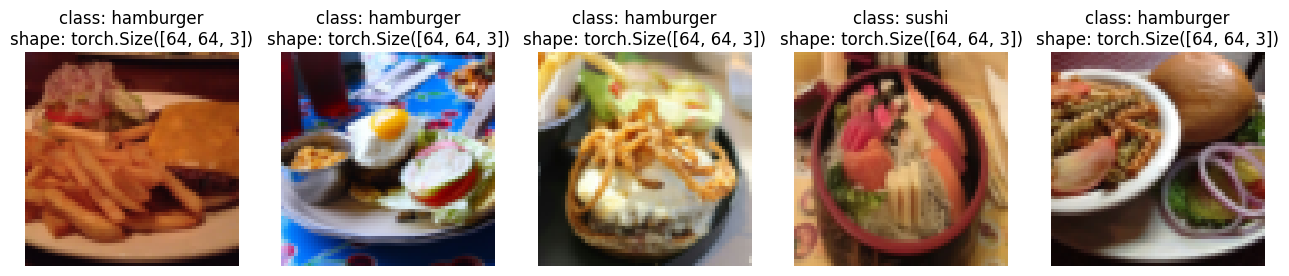

In [273]:
# Display random images from ImageFolder created Dataset
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=None)

For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


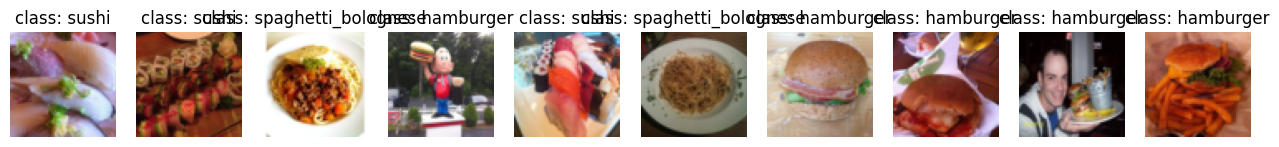

In [274]:
# Display random images from ImageFolderCustom Dataset
display_random_images(train_data_custom,
                      n=12,
                      classes=class_names,
                      seed=None) # Try setting the seed for reproducible images

# Data Augumentation:
Other forms of data augumentation
artificially expand the size and diversity of a training dataset by creating modified versions of existing data samples. This process helps to improve the generalization ability of ML models, prevent overfitting, and enhance overall model performance, especially when dealing with limited datasets.




In [278]:
# Trivial augument : SOTA PyTorch DA technique for vision models
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)), # resize
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

In [279]:
# Get all the image paths

Image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/hamburger/3563379.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/hamburger/2766731.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/hamburger/1611759.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/hamburger/734458.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/hamburger/510448.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/hamburger/78997.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/hamburger/740621.jpg'),
 PosixPath('/content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test/hamburger/1392659.jpg'),
 PosixPath('/content/drive/MyDrive/Cu

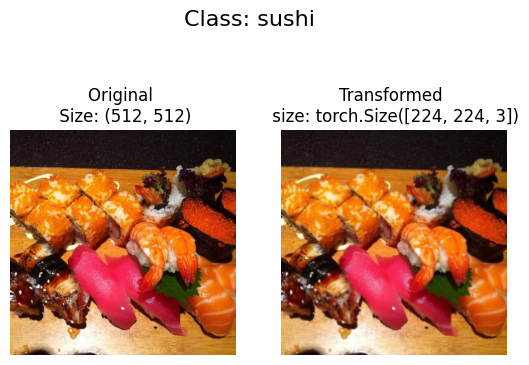

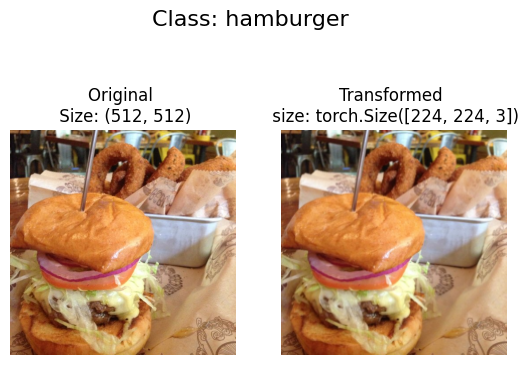

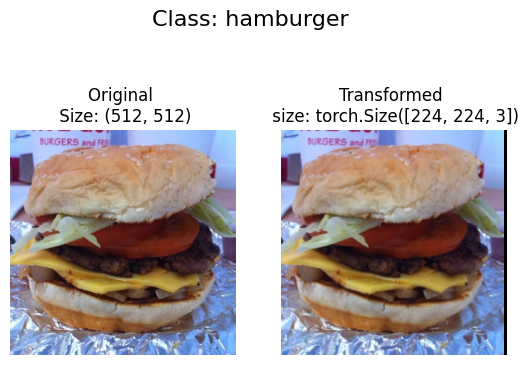

In [280]:
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transforms,
    n=3,
    seed=42
)


# Model 0: TinyVGG without data augumentation

Let's replicate TinyVGG architecture

* We have to create transform and loading the data for Model 0


In [289]:
# Updata sample traansforms
# Pipeline
simple_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=32),
    transforms.ToTensor()
    ])

In [290]:
simple_data_transform = CustomImageFolder(target_dir=train_dir, transform=simple_transforms)
simple_data_transform

In [291]:
simple_dataloader = DataLoader(simple_data_transform,
                               batch_size=10,
                               num_workers=os.cpu_count(),
                               shuffle=True)
simple_dataloader

In [292]:
# geting the image and thhe label from the Dataloader

img, label = next(iter(simple_dataloader))

print(f"Num of images: {len(img)},\nNum of labels: {len(label)}")
print(f"Size of image: {img.shape},\nSize of labels: {label.shape}")

Num of images: 10,
Num of labels: 10
Size of image: torch.Size([10, 3, 64, 64]),
Size of labels: torch.Size([10])


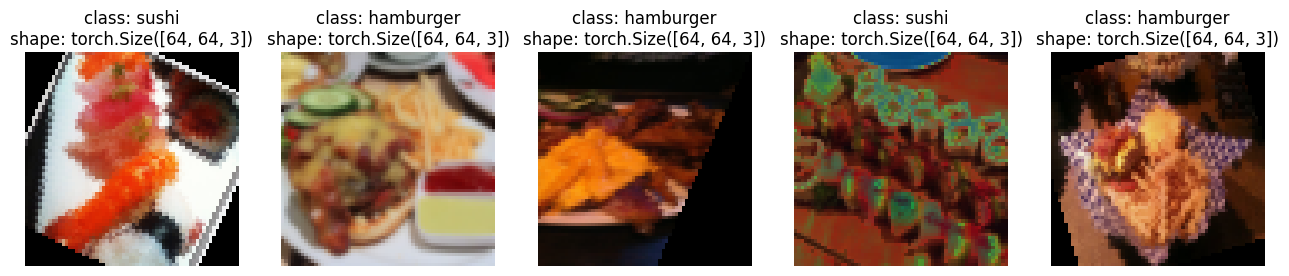

In [296]:
display_random_images(simple_data_transform,
                      n=5,
                      classes=class_names,
                      seed = 42
                      )

* Kernel Size → Defines the window size (e.g. 3×3) that scans the image to detect patterns — smaller captures fine details, larger captures broader features.

* Stride → Defines how far the kernel moves each step — higher stride = smaller output (less detail), lower stride = larger output (more detail).

* Padding → Adds extra pixels (usually zeros) around the image — helps preserve edge information and control output size (e.g. “same” keeps it same as input).

* MaxPool: Downsamples a feature map by taking the maximum value in each window, keeping only the most important features.

In [297]:
# Create Tiny VGG


class TinyVgg(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:

      super().__init__()
      self.conv_block_1 = nn.Sequential(

          nn.Conv2d(in_channels=input_shape,
                    out_channels=hidden_units,
                    kernel_size=3,
                    stride=1,
                    padding=1),

          nn.ReLU(),

          nn.Conv2d(in_channels=hidden_units,
                    out_channels=hidden_units,
                    kernel_size=3,
                    stride=1,
                    padding=1
                    ),
          nn.MaxPool2d(kernel_size=3,
                            stride=2))
      self.conv_block_2 = nn.Sequential(
                nn.Conv2d(in_channels=hidden_units,
                          out_channels=hidden_units,
                          kernel_size=3,
                          stride=1,
                          padding=1),
                nn.ReLU(),
                nn.Conv2d(in_channels=hidden_units,
                          out_channels=hidden_units,
                          kernel_size=3,
                          stride=1,
                          padding=1
                          ),
                nn.MaxPool2d(kernel_size=3,
                            stride=2) # default stride value is same as the kernel_size
            )
      self.classifier = nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features=hidden_units*15*15,
                    out_features=output_shape)
          )

  def forward(self, x):

    x = self.conv_block_1(x)

    x= self.conv_block_2(x)

    x = self.classifier(x)

    return x
    # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # benefits from `operator fusion` speed up how gpu performs computation


In [298]:
torch.manual_seed(42)
model_0 = TinyVgg(input_shape=3,
                  hidden_units=20,
                  output_shape=len(class_names)).to(device)

In [299]:
model_0

TinyVgg(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4500, out_features=3, bias=True)
  )
)

In [300]:
# Tring a gforward pass on a single image

image_batch, label_batch = next(iter(simple_dataloader))
image_batch.shape, label_batch.shape


(torch.Size([10, 3, 64, 64]), torch.Size([10]))

In [301]:
model_0(image_batch.to(device))

tensor([[-2.9503e-03, -9.8042e-03, -6.0422e-04],
        [ 2.3557e-03, -4.9500e-03,  1.0889e-03],
        [ 4.7627e-03, -2.4279e-03,  2.1479e-02],
        [ 7.3849e-04, -7.0546e-03,  8.6254e-03],
        [ 6.6475e-03, -3.1103e-03,  3.4838e-03],
        [ 2.4810e-03, -4.9991e-03,  1.5247e-02],
        [ 7.6248e-03, -5.1727e-03,  5.7689e-03],
        [-8.8711e-05, -6.8951e-03,  1.3164e-02],
        [-5.6718e-04, -5.8477e-03,  7.8834e-03],
        [-6.2083e-03, -5.1923e-03,  6.2627e-04]], grad_fn=<AddmmBackward0>)

In [302]:
!pip install torchinfo

In [303]:
from torchinfo import summary

model = model_0
batch_size = 16
input_size = [1,3,64,64]
summary(model,
        input_size)

Layer (type:depth-idx)                   Output Shape              Param #
TinyVgg                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 20, 31, 31]           --
│    └─Conv2d: 2-1                       [1, 20, 64, 64]           560
│    └─ReLU: 2-2                         [1, 20, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 20, 64, 64]           3,620
│    └─MaxPool2d: 2-4                    [1, 20, 31, 31]           --
├─Sequential: 1-2                        [1, 20, 15, 15]           --
│    └─Conv2d: 2-5                       [1, 20, 31, 31]           3,620
│    └─ReLU: 2-6                         [1, 20, 31, 31]           --
│    └─Conv2d: 2-7                       [1, 20, 31, 31]           3,620
│    └─MaxPool2d: 2-8                    [1, 20, 15, 15]           --
├─Sequential: 1-3                        [1, 3]                    --
│    └─Flatten: 2-9                      [1, 4500]                 --
│    

In [304]:
# Creating a training and testing loop
import torch
from torch import nn

In [305]:
def train_step(model : torch.nn.Module,
               dataloader : torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               optimizer : torch.optim.Optimizer):
    # Put model in trainmode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):

      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculate and accumulate the loss
      loss = loss_fn(y_pred, y)
      train_loss += loss.item()

      # 3. OPtimizer zero grad
      optimizer.zero_grad()

      # 4. Loss backward
      loss.backward()

      # 5. optimizer step
      optimizer.step()

      # Calculate and accumulate acuracy
      y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
      train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrice to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [306]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn : torch.nn.Module):
  # Put model on eval mode
  model.eval()

  # Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager : as disabling gradients for faster computation
  with torch.inference_mode():
    # Loop through DataLoder Batches
    for batch, (X, y) in enumerate(dataloader):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred_logits = model(X)

      # 2. Calculate the loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # Calculate and accumulate accuracy
      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

# Creating train function to combine train_step() and test_step()

* Take in a model, a `DataLoader` for training and test sets, an optimizer, a loss function and how many epochs to perform each train and test step for.
* Create an empty results dictionary for train_loss, train_acc, test_loss and test_acc values (we can fill this up as training goes on).
* Loop through training and test step function for a number of epochs.
* Print out what's happening at the end of each epoch.
* Update the empty results dictionary with the updated metrics each epoch.
* Return the filled


In [307]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader : torch.utils.data.DataLoader,
          test_dataloader : torch.utils.data.DataLoader,
          optimizer : torch.optim.Optimizer,
          loss_fn : torch.nn.Module = nn.CrossEntropyLoss(),
          epochs : int = 5):
  # Create an empty results dictionary
  results = {"train_loss" : [],
             "train_acc" : [],
             "test_loss" : [],
             "test_acc" : []
             }

  # Loop through training and testing stages for a number of epochs
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)

    #4 Print out what's happening
    print(
        f"Epoch: {epoch+1} | "
        f"train_loss: {train_loss :.4f} | "
        f"train_acc: {train_acc:.4f} | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc:.4f}"
    )

    # Update results dictionary
    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
    results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)


  # 6. Retune the filled results at the end of the epochs
  return results

In [308]:
# Train and Evaluate Model 0, for it we need to now compine the train(), dataloader and model:

# set random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Ser number of epochs
NUM_EPOCHS = 20

# Recreate an instance of TinyVGG
model_0 = TinyVgg(input_shape=3,
                  hidden_units=10,
                  output_shape = len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_custom,
                        test_dataloader=test_dataloader_custom,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS
                        )
# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0144 | train_acc: 0.4689 | test_loss: 0.8927 | test_acc: 0.5267
Epoch: 2 | train_loss: 0.9370 | train_acc: 0.5267 | test_loss: 0.9171 | test_acc: 0.5200
Epoch: 3 | train_loss: 0.9364 | train_acc: 0.5556 | test_loss: 0.8892 | test_acc: 0.5400
Epoch: 4 | train_loss: 0.8781 | train_acc: 0.5622 | test_loss: 0.8865 | test_acc: 0.5333
Epoch: 5 | train_loss: 0.8426 | train_acc: 0.5978 | test_loss: 0.9375 | test_acc: 0.5667
Epoch: 6 | train_loss: 0.8102 | train_acc: 0.6289 | test_loss: 0.8364 | test_acc: 0.5933
Epoch: 7 | train_loss: 0.7712 | train_acc: 0.6733 | test_loss: 0.9609 | test_acc: 0.5267
Epoch: 8 | train_loss: 0.7282 | train_acc: 0.6689 | test_loss: 0.8195 | test_acc: 0.6267
Epoch: 9 | train_loss: 0.7051 | train_acc: 0.6867 | test_loss: 0.8614 | test_acc: 0.6333
Epoch: 10 | train_loss: 0.6737 | train_acc: 0.7178 | test_loss: 0.8814 | test_acc: 0.6400
Epoch: 11 | train_loss: 0.6531 | train_acc: 0.7289 | test_loss: 0.7902 | test_acc: 0.6267
Epoch: 12 | train_l

## Plot the loss curves

In [309]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

We'll need to extract each of these keys and turn them into a plot.

In [310]:
import matplotlib.pyplot as plt
def plot_loss_curves(results: Dict[str, List[float]]):
  """
  Plot training curves of a results dictionary.

  Args:
  result (dict) : dictionary containing list of values, e.g.
  {
    "train_loss" : [...],
    "train_acc" : [...],
    "test_loss" : [...],
    "test_acc" : [...]
  }
  """

  # Get the loss values of the results dictionary (training and test)
  loss = results['train_loss']
  test_loss = results["test_loss"]

  # Get the accuracy values of the results dictionary (training and test)
  train_acc = results["train_acc"]
  test_acc = results["test_acc"]

  # how many epochs there where
  epochs = range(len(results["train_loss"]))

  # Setup the plot
  plt.figure(figsize=(15,7))

  # Plot Loss
  plt.subplot(1,2,1)
  plt.plot(epochs, loss, label="Train Loss")
  plt.plot(epochs, test_loss, label="Test Loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  # Plot accuracy
  plt.subplot(1,2,2)
  plt.plot(epochs, train_acc, label="Train Accuracy")
  plt.plot(epochs, test_loss, label="Test Accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

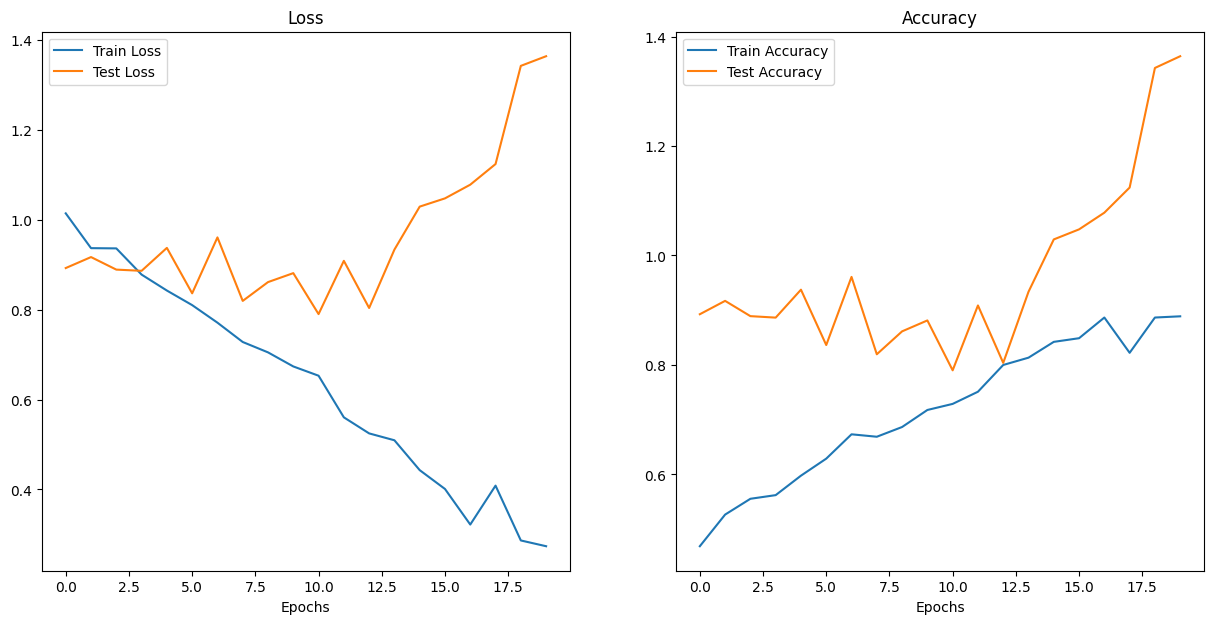

In [311]:
plot_loss_curves(model_0_results)

# Loss Curves
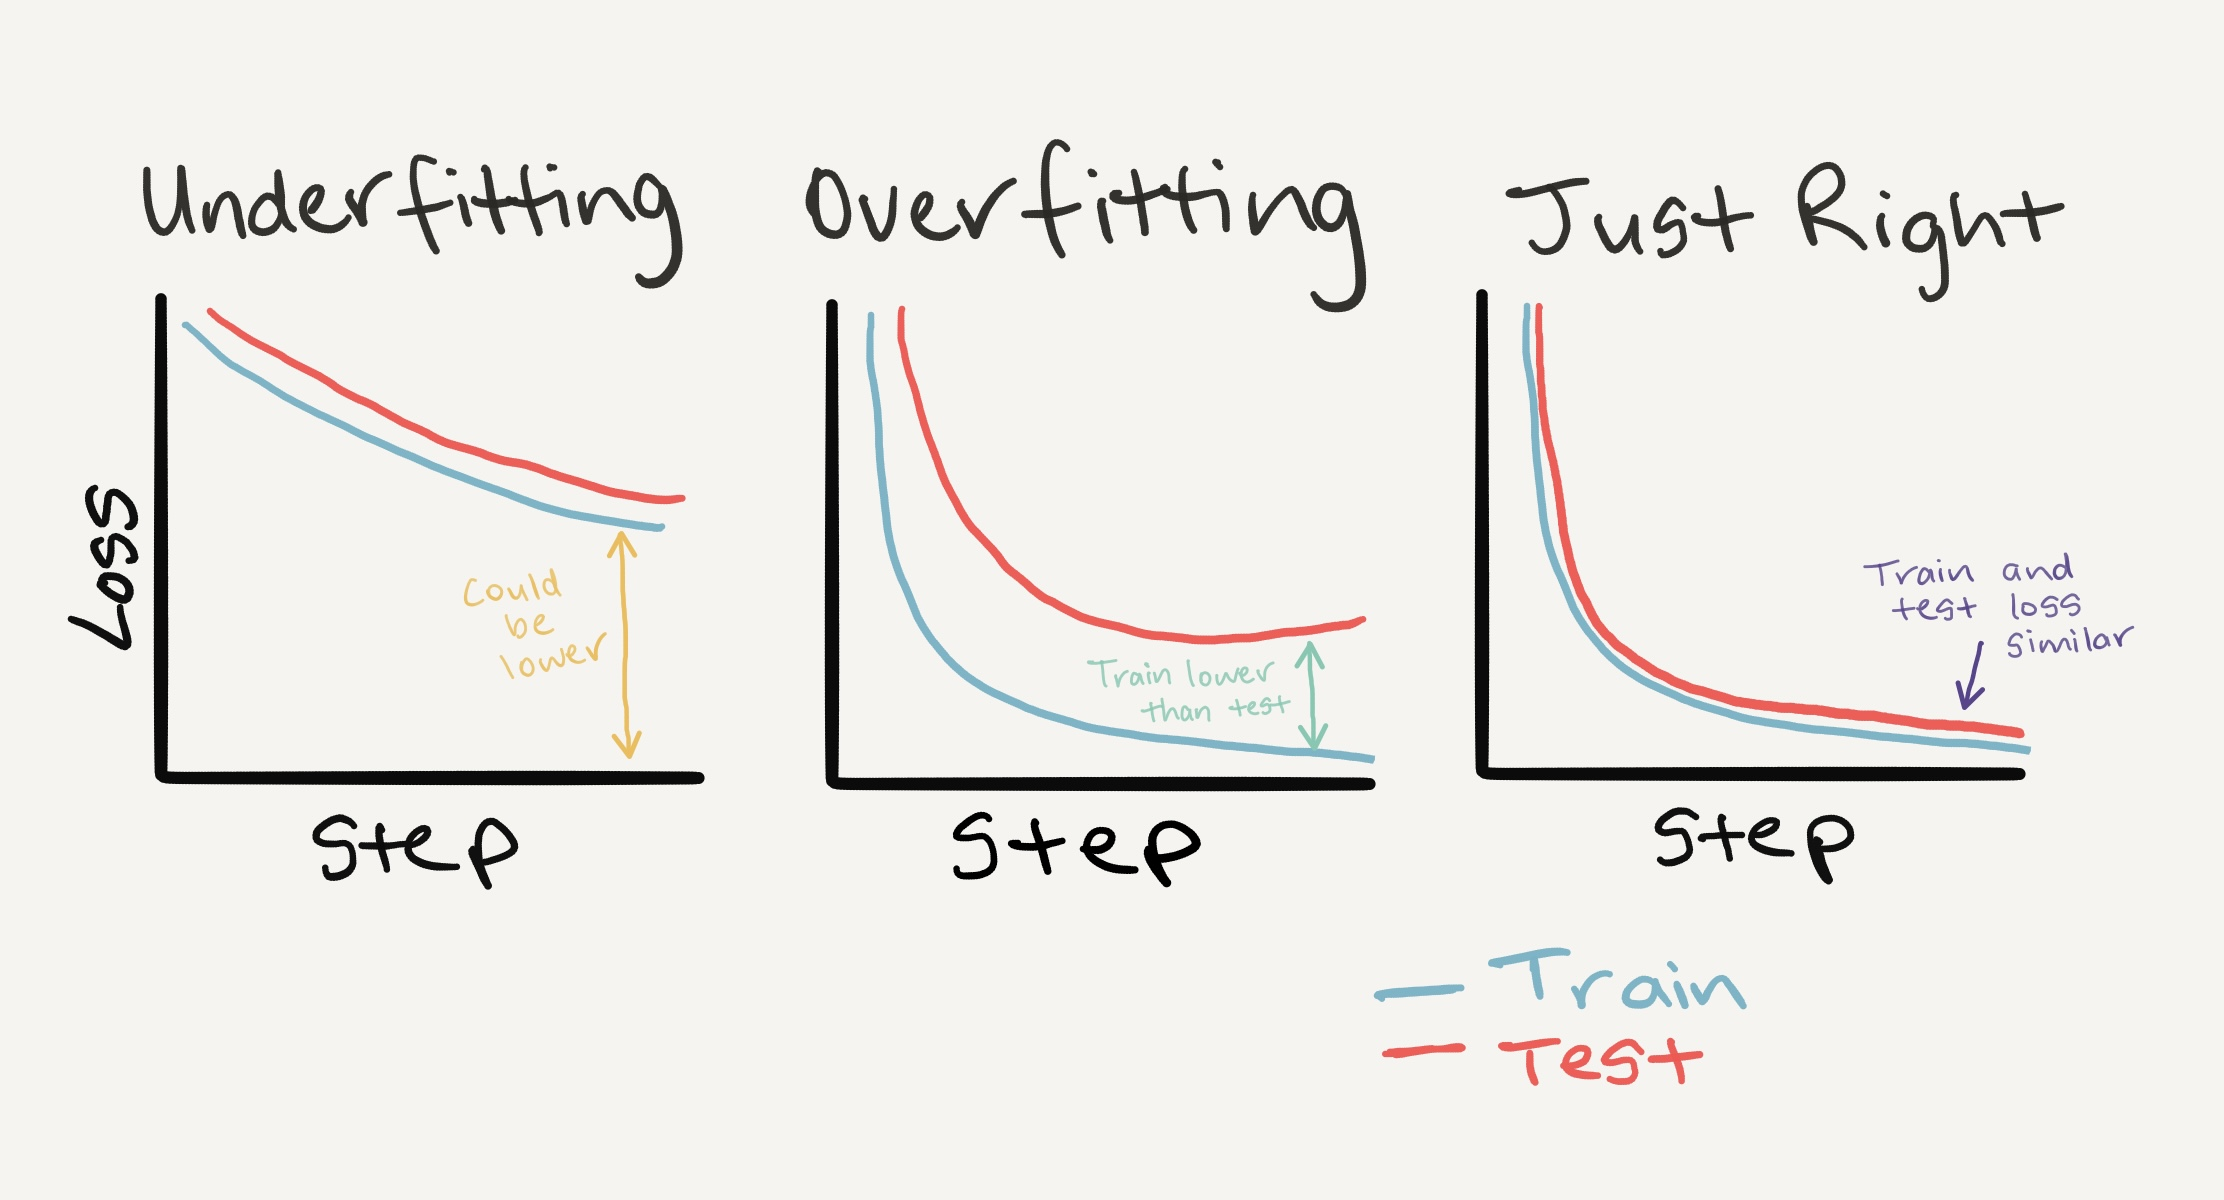

### How to deal with overfitting

##### Regularization

Methods
* Get more data
* Simplify your model- Reduce the number of hidden units
* Use data augumentation - make it harder for model to learn
* Use transfer learning - Use the pretrained model's weight, by tweaking it a lil bit for food images specefically
* Use dropout layers - Dropout layers randomly remove connections between hidden layers in neural netwroks.
* Use learning rate decay - decrease the learning rate slowly. the closer you gate to the convergence the smaller the larning rate or (step).
* Use early stopping - Stop the model training before it begins to overfit.

### How to deal with underfitting
###### Increase models predective power
Methods:
* Add more layes/hidden units in your model
* Tweak the learning rate
* Use transfer learning
* Train for longer
* Use less regularization


# Model 1: TinnyVgg with Data Augumentation

In [312]:
# create transformwith data augumentation
from torchvision import transforms
train_transform_trivial_augument = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

# Create testing transforms (no data augumentation)
test_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

Create train and test `Dataset's` and `Dataloader's`

In [313]:
# Turn image folders into Datasets
train_data_augmented = datasets.ImageFolder(train_dir, transform = train_transform_trivial_augument)
test_simple = datasets.ImageFolder(test_dir, transform=test_transform)
train_data_augmented, test_simple

(Dataset ImageFolder
     Number of datapoints: 450
     Root location: /content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 150
     Root location: /content/drive/MyDrive/Custom_Dataset/data/hamburger_sushi_spaghetti_bolognese/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [314]:
# Turn Datasets into DataLoader's
import os
BATCH_SIZE = 32
NUM_WORKERS= int(os.cpu_count())

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(train_data_augmented,
                                         batch_size=BATCH_SIZE,
                                         shuffle=True,
                                         num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=True,
                                    num_workers=NUM_WORKERS)

train_dataloader_augmented, test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x7db4ce13d9a0>,
 <torch.utils.data.dataloader.DataLoader at 0x7db4cdeb6600>)

# Construct and Train Model 1

In [315]:
torch.manual_seed(42)
model_1 = TinyVgg(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_augmented.classes)).to(device)

model_1

TinyVgg(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2250, out_features=3, bias=True)
  )
)

In [316]:
# Train

# Set seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 20

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer =torch.optim.Adam(params=model_1.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader = test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1119 | train_acc: 0.3438 | test_loss: 1.1132 | test_acc: 0.3074
Epoch: 2 | train_loss: 1.0965 | train_acc: 0.3292 | test_loss: 1.0624 | test_acc: 0.5125
Epoch: 3 | train_loss: 1.0295 | train_acc: 0.5062 | test_loss: 0.9795 | test_acc: 0.5199
Epoch: 4 | train_loss: 0.9786 | train_acc: 0.5375 | test_loss: 0.9703 | test_acc: 0.5159
Epoch: 5 | train_loss: 0.9651 | train_acc: 0.5458 | test_loss: 0.9362 | test_acc: 0.5437
Epoch: 6 | train_loss: 0.9628 | train_acc: 0.5125 | test_loss: 0.9287 | test_acc: 0.5312
Epoch: 7 | train_loss: 0.9576 | train_acc: 0.5083 | test_loss: 0.9320 | test_acc: 0.5312
Epoch: 8 | train_loss: 0.9655 | train_acc: 0.5396 | test_loss: 0.9176 | test_acc: 0.5528
Epoch: 9 | train_loss: 0.9757 | train_acc: 0.5312 | test_loss: 0.9362 | test_acc: 0.5369
Epoch: 10 | train_loss: 0.9461 | train_acc: 0.5458 | test_loss: 0.8925 | test_acc: 0.5767
Epoch: 11 | train_loss: 0.9682 | train_acc: 0.5125 | test_loss: 0.9193 | test_acc: 0.5523
Epoch: 12 | train_l

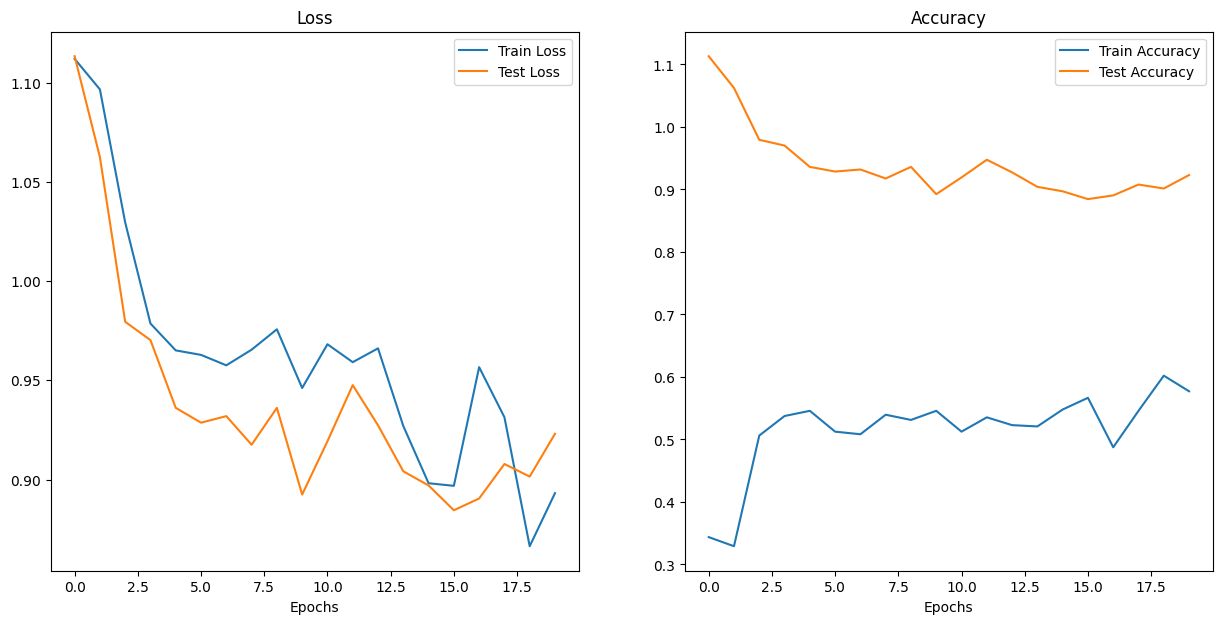

In [317]:
plot_loss_curves(model_1_results)

In [318]:
### COmpare model results

import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.014386,0.468889,0.892686,0.526667
1,0.936970,0.526667,0.917101,0.520000
2,0.936428,0.555556,0.889195,0.540000
3,0.878108,0.562222,0.886508,0.533333
4,0.842645,0.597778,0.937529,0.566667
5,0.810215,0.628889,0.836426,0.593333
6,0.771150,0.673333,0.960868,0.526667
7,0.728159,0.668889,0.819547,0.626667
8,0.705056,0.686667,0.861402,0.633333
9,0.673749,0.717778,0.881361,0.640000


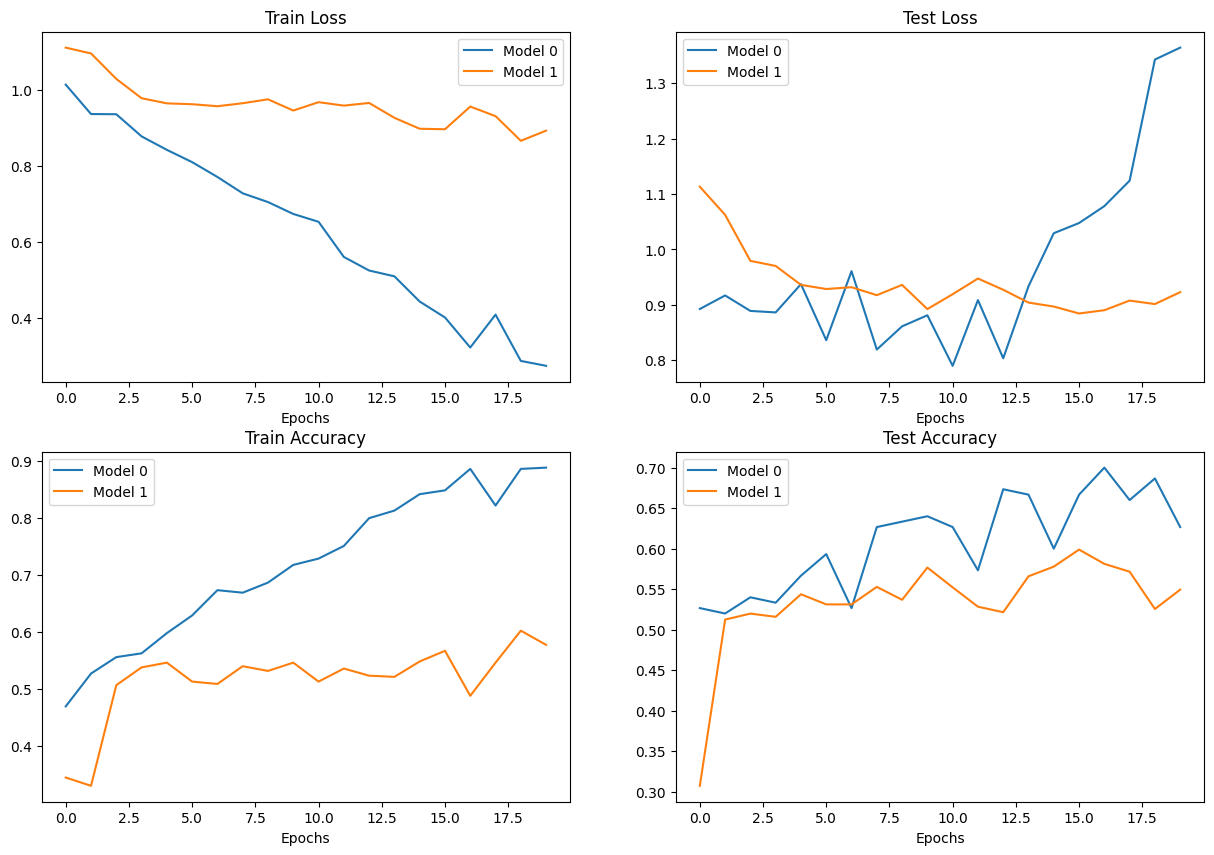

In [319]:
# Setup a plot
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();

# Make predicitions on a custom image



In [325]:
# Download custom image and turn it into a tensor


# Setup custom image path
sushi_img= "/content/drive/MyDrive/Custom_Dataset/Custom_image_prediction/Sushi.jpg"
burger_img = "/content/drive/MyDrive/Custom_Dataset/Custom_image_prediction/Hamburger.jpg"
spaghetti_img = "/content/drive/MyDrive/Custom_Dataset/Custom_image_prediction/Spagheti.jpg"

In [326]:
# Loading in a custom image with PyTorch

import torchvision

# Read in custom_image
custom_image_uint8_1 = torchvision.io.read_image(str(sushi_img))
custom_image_uint8_2 = torchvision.io.read_image(str(burger_img))
custom_image_uint8_3 = torchvision.io.read_image(str(spaghetti_img))
# Print out image data
print(f"Custom image tensor:\n{custom_image_uint8_1}\n")
print(f"Custom image shape: {custom_image_uint8_1.shape}")
print(f"Custom image dtype: {custom_image_uint8_1.dtype}\n")
print(f"Custom image tensor:\n{custom_image_uint8_2}\n")
print(f"Custom image shape: {custom_image_uint8_2.shape}")
print(f"Custom image dtype: {custom_image_uint8_2.dtype}\n")
print(f"Custom image tensor:\n{custom_image_uint8_3}\n")
print(f"Custom image shape: {custom_image_uint8_3.shape}")
print(f"Custom image dtype: {custom_image_uint8_3.dtype}\n")


Custom image tensor:
tensor([[[ 47,  47,  47,  ...,  67,  67,  67],
         [ 47,  47,  47,  ...,  67,  67,  67],
         [ 47,  47,  47,  ...,  68,  68,  68],
         ...,
         [ 32,  33,  35,  ..., 152, 151, 150],
         [ 31,  32,  34,  ..., 150, 149, 148],
         [ 31,  32,  34,  ..., 149, 148, 147]],

        [[ 50,  50,  50,  ...,  65,  65,  65],
         [ 50,  50,  50,  ...,  65,  65,  65],
         [ 50,  50,  50,  ...,  66,  66,  66],
         ...,
         [ 68,  69,  71,  ..., 152, 151, 150],
         [ 67,  68,  70,  ..., 150, 149, 148],
         [ 67,  68,  70,  ..., 149, 148, 147]],

        [[ 69,  69,  69,  ..., 102, 102, 102],
         [ 69,  69,  69,  ..., 102, 102, 102],
         [ 69,  69,  69,  ..., 103, 103, 103],
         ...,
         [  0,   0,   0,  ..., 178, 177, 176],
         [  0,   0,   0,  ..., 176, 175, 174],
         [  0,   0,   0,  ..., 175, 174, 173]]], dtype=torch.uint8)

Custom image shape: torch.Size([3, 1200, 1200])
Custom image dtyp

In [329]:
# Load in custom image and convert the tesor values to float32
custom_image_1 = torchvision.io.read_image(str(sushi_img)).type(torch.float32)
custom_image_2 = torchvision.io.read_image(str(burger_img)).type(torch.float32)
custom_image_3 = torchvision.io.read_image(str(spaghetti_img)).type(torch.float32)

# Divide the image pixel values by 225 to get them between [0, 1]
custom_image_1 = custom_image_1 / 255
custom_image_2 = custom_image_2 / 255
custom_image_3 = custom_image_3 / 255
# Print image data
print(f"Custom image tensor:\n{custom_image_1}\n")
print(f"Custom image shape: \n {custom_image_1.shape}")
print(f"Custom image dtype: \n {custom_image_1.dtype}\n")

print(f"Custom image tensor:\n{custom_image_2}\n")
print(f"Custom image shape: \n {custom_image_2.shape}")
print(f"Custom image dtype: \n {custom_image_2.dtype}\n")

print(f"Custom image tensor:\n{custom_image_3}\n")
print(f"Custom image shape: \n {custom_image_3.shape}")
print(f"Custom image dtype: \n {custom_image_3.dtype}\n")

Custom image tensor:
tensor([[[0.1843, 0.1843, 0.1843,  ..., 0.2627, 0.2627, 0.2627],
         [0.1843, 0.1843, 0.1843,  ..., 0.2627, 0.2627, 0.2627],
         [0.1843, 0.1843, 0.1843,  ..., 0.2667, 0.2667, 0.2667],
         ...,
         [0.1255, 0.1294, 0.1373,  ..., 0.5961, 0.5922, 0.5882],
         [0.1216, 0.1255, 0.1333,  ..., 0.5882, 0.5843, 0.5804],
         [0.1216, 0.1255, 0.1333,  ..., 0.5843, 0.5804, 0.5765]],

        [[0.1961, 0.1961, 0.1961,  ..., 0.2549, 0.2549, 0.2549],
         [0.1961, 0.1961, 0.1961,  ..., 0.2549, 0.2549, 0.2549],
         [0.1961, 0.1961, 0.1961,  ..., 0.2588, 0.2588, 0.2588],
         ...,
         [0.2667, 0.2706, 0.2784,  ..., 0.5961, 0.5922, 0.5882],
         [0.2627, 0.2667, 0.2745,  ..., 0.5882, 0.5843, 0.5804],
         [0.2627, 0.2667, 0.2745,  ..., 0.5843, 0.5804, 0.5765]],

        [[0.2706, 0.2706, 0.2706,  ..., 0.4000, 0.4000, 0.4000],
         [0.2706, 0.2706, 0.2706,  ..., 0.4000, 0.4000, 0.4000],
         [0.2706, 0.2706, 0.2706,  ..

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

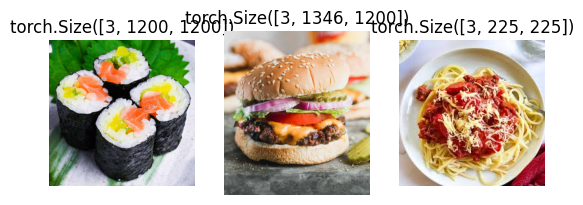

In [332]:
plt.subplot(1,3,1)

plt.imshow(custom_image_1.permute(1,2,0)) # CHW -> HWC
plt.title(custom_image_1.shape)
plt.axis(False)

plt.subplot(1,3,2)

plt.imshow(custom_image_2.permute(1,2,0)) # CHW -> HWC
plt.title(custom_image_2.shape)
plt.axis(False)

plt.subplot(1,3,3)

plt.imshow(custom_image_3.permute(1,2,0)) # CHW -> HWC
plt.title(custom_image_3.shape)
plt.axis(False)

In [358]:
# Create transform pipeline to resize image
custom_image_transform = transforms.Compose([
    transforms.Resize((64,64))
])

# Transform target image
custom_image_transformed_1 = custom_image_transform(custom_image_1)
custom_image_transformed_2 = custom_image_transform(custom_image_2)
custom_image_transformed_3 = custom_image_transform(custom_image_3)
# Print out original shape and new shape
print(f"Original shape: {custom_image_1.shape}")
print(f"New shape: {custom_image_transformed_1.shape}")

Original shape: torch.Size([3, 1200, 1200])
New shape: torch.Size([3, 64, 64])


In [359]:
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed_1)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x225 and 2250x3)

Our model expects image tensors with a batch size dimension at the start (NCHW where N is the batch size).

Except our custom image is currently only CHW

In [360]:
model_1.eval()
with torch.inference_mode():
  # Add an extra dimention to image
  custom_image_transformed_with_batch_size_1 = custom_image_transformed_1.unsqueeze(dim=0)
  custom_image_transformed_with_batch_size_2 = custom_image_transformed_2.unsqueeze(dim=0)
  custom_image_transformed_with_batch_size_3 = custom_image_transformed_3.unsqueeze(dim=0)
  # Print out different shapes
  print(f"Custom image transformed shape : {custom_image_transformed_1.shape}")
  print(f"Unsqueeze custom image shape : {custom_image_transformed_with_batch_size_1.shape}" )

  # Make a prediction on image with an extra dimention
  custom_image_pred_1 = model_1(custom_image_transformed_1.unsqueeze(dim=0).to(device))
  custom_image_pred_2 = model_1(custom_image_transformed_2.unsqueeze(dim=0).to(device))
  custom_image_pred_3 = model_1(custom_image_transformed_3.unsqueeze(dim=0).to(device))


Custom image transformed shape : torch.Size([3, 64, 64])
Unsqueeze custom image shape : torch.Size([1, 3, 64, 64])


Classical Reccurent issues in pytorch:
* Wrong datatype
* Wrong device
* Wrong shapes

In [361]:
custom_image_pred_1, custom_image_pred_2, custom_image_pred_3

(tensor([[ 0.2544, -1.5624,  1.0690]]),
 tensor([[ 0.1716, -0.1340, -0.1182]]),
 tensor([[-0.1474,  0.6887, -0.3958]]))

It is still in logit form we need to convert it from:

`Logits`->`Prediction Probabilities`->`Prediction Labels`

In [362]:
# Logits
print(f"Prediction Logits: {custom_image_pred}")

# Prediction Probabilities
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
print(f"Prediction probabilities: {custom_image_pred_probs}")

# Convert prediction probabilities -> prediction labesl
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
print(f"Prediction label: {custom_image_pred_label}")


Prediction Logits: tensor([[ 0.2544, -1.5624,  1.0690]])
Prediction probabilities: tensor([[0.2923, 0.0475, 0.6601]])
Prediction label: tensor([2])


In [363]:
#Alright!
# Lets find the prediction label
custom_image_pred_class = class_names[custom_image_pred_label.cpu()]
print(f"Predicted class is: {custom_image_pred_class}")

Predicted class is: sushi


In [364]:
model_1.eval()
with torch.inference_mode():
  custom_image_transformed_with_batch_size_1 = custom_image_transformed_1.unsqueeze(dim=0)
  custom_image_transformed_with_batch_size_2 = custom_image_transformed_2.unsqueeze(dim=0)
  custom_image_transformed_with_batch_size_3 = custom_image_transformed_3.unsqueeze(dim=0)

  custom_image_1_pred = model_1(custom_image_transformed_with_batch_size_1.to(device))
  custom_image_2_pred = model_1(custom_image_transformed_with_batch_size_2.to(device))
  custom_image_3_pred = model_1(custom_image_transformed_with_batch_size_3.to(device))

custom_image_1_pred, custom_image_2_pred,custom_image_3_pred


(tensor([[ 0.2544, -1.5624,  1.0690]]),
 tensor([[ 0.1716, -0.1340, -0.1182]]),
 tensor([[-0.1474,  0.6887, -0.3958]]))

In [365]:
custom_image_predicted_prebailities_1 = torch.softmax(custom_image_1_pred, dim=1)
custom_image_label_1 = torch.argmax(custom_image_predicted_prebailities_1, dim=1)
cust_img_class_1 = class_names[custom_image_label_1.to(device)]

custom_image_predicted_prebailities_2 = torch.softmax(custom_image_2_pred, dim=1)
custom_image_label_2 = torch.argmax(custom_image_predicted_prebailities_2, dim=1)
cust_img_class_2 = class_names[custom_image_label_2.to(device)]

custom_image_predicted_prebailities_3 = torch.softmax(custom_image_3_pred, dim=1)
custom_image_label_3 = torch.argmax(custom_image_predicted_prebailities_3, dim=1)
cust_img_class_3 = class_names[custom_image_label_3.to(device)]

cust_img_class_1, cust_img_class_2, cust_img_class_3

('sushi', 'hamburger', 'spaghetti_bolognese')

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

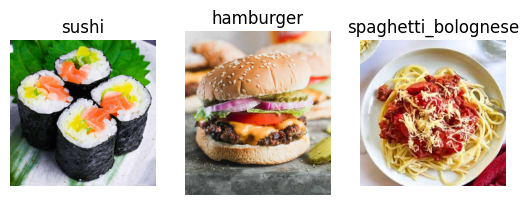

In [366]:
plt.subplot(1,3,1)

plt.imshow(custom_image_1.permute(1,2,0)) # CHW -> HWC
plt.title(cust_img_class_1)
plt.axis(False)

plt.subplot(1,3,2)

plt.imshow(custom_image_2.permute(1,2,0)) # CHW -> HWC
plt.title(cust_img_class_2)
plt.axis(False)

plt.subplot(1,3,3)

plt.imshow(custom_image_3.permute(1,2,0)) # CHW -> HWC
plt.title(cust_img_class_3)
plt.axis(False)